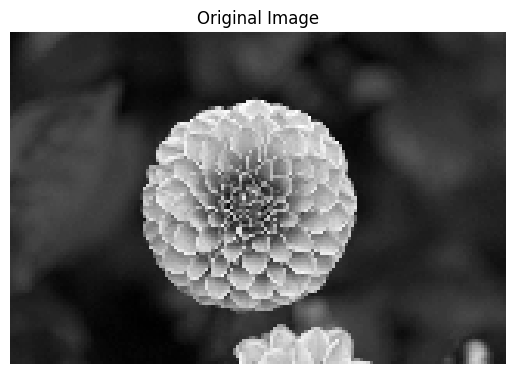

Image shape: (107, 160)
Pixel values range: 3 to 211
Original size: 17120
Original size: 17120
Components shape: (10, 160)
Transformed shape: (107, 10)
Components storage: 1600
Coefficients storage: 1070
Compressed size: 2670
Ratio: 6.411985018726591


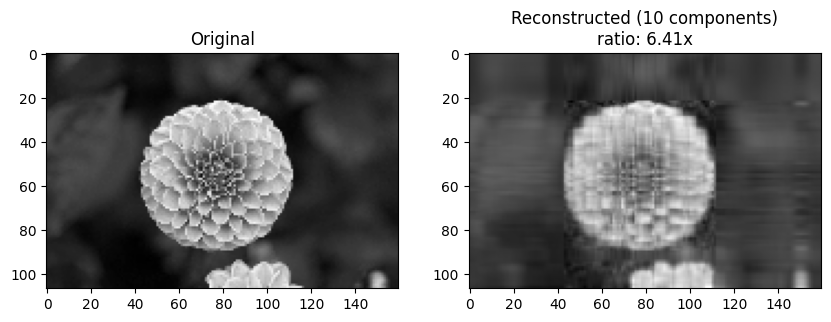

Original size: 17120
Original size: 17120
Components shape: (1, 160)
Transformed shape: (107, 1)
Components storage: 160
Coefficients storage: 107
Compressed size: 267
Ratio: 64.11985018726591


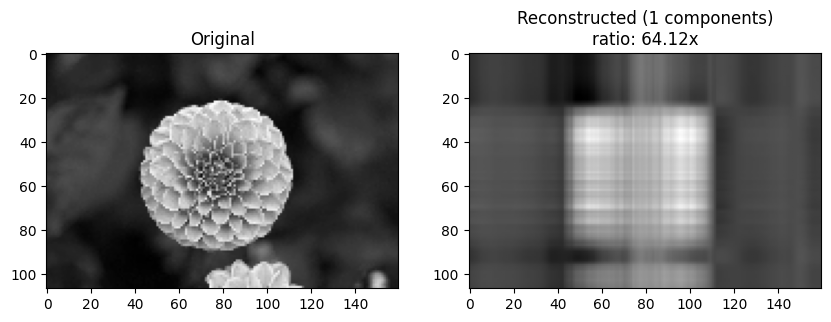

Original size: 17120
Original size: 17120
Components shape: (50, 160)
Transformed shape: (107, 50)
Components storage: 8000
Coefficients storage: 5350
Compressed size: 13350
Ratio: 1.2823970037453183


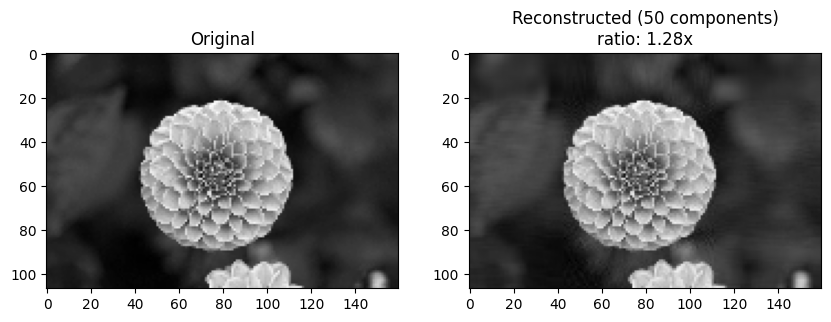

Original size: 17120
Original size: 17120
Components shape: (100, 160)
Transformed shape: (107, 100)
Components storage: 16000
Coefficients storage: 10700
Compressed size: 26700
Ratio: 0.6411985018726591


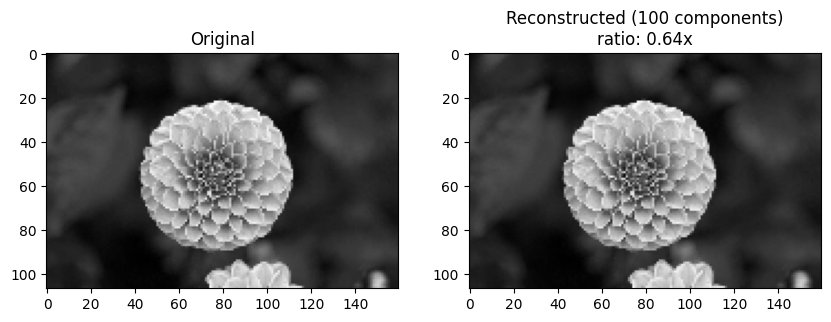

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple
import sys
sys.path.append('../lib/algorithms')
from PCA import PCA
from sklearn.datasets import load_sample_image

### USING SKLEARN ONLY TO GET AN IMAGE.

def load_sample_image_simple() -> np.ndarray:
    """
    Load a sample grayscale image for compression experiments.

    Returns:
        2D numpy array of shape (height, width) with pixel values
    """
    img = load_sample_image('flower.jpg')
    img_gray = img.mean(axis=2)
    img_small = img_gray[::4, ::4]

    return img_small.astype(np.uint8)
    
def compress_image_pca(image: np.ndarray, n_components: int) -> Tuple[np.ndarray, float, 'PCA']:
    """
    Compress a single image using PCA

    Strategy: Treat each row of the image as a data point, each column
    as a feature. Find principal components across rows.

    Args:
        image: 2D array of shape (height, width)
        n_components: Number of principal components to keep

    Returns:
        reconstruced: reconstructed image
        compression_ratio: Original size / compressed size
        pca: Fitted PCA object

    How it works:
    1. Each row of the image is a 1D vector of pixel values
    2. We have 'height' such vectors, each with 'width' features
    3. PCA finds patterns across these row vectors
    4. We keep only top n_components patterns
    5. Reconstruct the image from these components

    Compression ratio calculation:
    - Original: height * width values
    - Compressed: n_components * width (components) +
                  n_components * height (coefficients)
    """
    image_pca = PCA(n_components)
    transformed_image = image_pca.fit_transform(image)
    reconstructed_image = image_pca.inverse_transform(transformed_image)
    original_size = image.shape[0] * image.shape[1]
    compressed_size = (image_pca.components_.shape[0] * image_pca.components_.shape[1]) + \
    (transformed_image.shape[0] * transformed_image.shape[1]) 
    compression_ratio = original_size / compressed_size
    print(f"Original size: {original_size}")
    print(f"Original size: {original_size}")
    print(f"Components shape: {image_pca.components_.shape}")
    print(f"Transformed shape: {transformed_image.shape}")
    print(f"Components storage: {image_pca.components_.shape[0] * image_pca.components_.shape[1]}")
    print(f"Coefficients storage: {transformed_image.shape[0] * transformed_image.shape[1]}")
    print(f"Compressed size: {compressed_size}")
    print(f"Ratio: {compression_ratio}")
    return (reconstructed_image, compression_ratio, image_pca)
            
    

#Load and Visualize
original_image = load_sample_image_simple()
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

print(f"Image shape: {original_image.shape}")
print(f"Pixel values range: {original_image.min()} to {original_image.max()}")

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=10)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (10 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=1)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (1 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=50)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (50 components)\nratio: {ratio:.2f}x')
plt.show()

reconstructed, ratio, pca = compress_image_pca(original_image, n_components=100)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(original_image, cmap='gray')
plt.title('Original')

plt.subplot(1,2,2)
plt.imshow(reconstructed, cmap='gray')
plt.title(f'Reconstructed (100 components)\nratio: {ratio:.2f}x')
plt.show()

    